# A coding agent on one RTX 3090: Qwen3.8-Flash-Next IQ2_XS (Strata) + Pi

**Verdict (measured, 2026-10-04):** one consumer GPU serves a usable coding agent. Pi on Qwen3.8-Flash-Next IQ2_XS built a working
3D ISS tracker (correct sun position and ISS position) in two runs, **but only after two fixes**:

1. **Trim the skill catalog.** 60 installed skills cost **9,532 prompt tokens on every turn** (11,888 vs 2,356).
2. **Raise the context window.** At 40,960 tokens, two build attempts ran out of context before writing any app file. At 262,144 tokens, the build finished.

Single user, one RTX 3090 24 GB, 16 vCPU, 40 GiB RAM. Labels follow [`docs/methodology.md`](../../docs/methodology.md): **measured** = receipt in `receipts/`.

## Credits

- **Strata** inference engine: authored by Niko ([@Niko1221](https://github.com/Niko1221)), [Niko1221/Strata](https://github.com/Niko1221/Strata) @ [`7df6cbc`](https://github.com/Niko1221/Strata/commit/7df6cbcf6dbef62ca98cddf38710ee6cde8a0f51) (MIT). Our image only rebuilds it for sm86.
- **Qwen3.8-Flash-Next GSQ-RCO GGUF** (IQ2_XS) quantization: authored by [ISTA-DASLab](https://huggingface.co/ISTA-DASLab), [model card](https://huggingface.co/ISTA-DASLab/Qwen3.8-Flash-Next-GSQ-RCO-GGUF) (Apache-2.0); base model [Qwen/Qwen3.8-Flash-Next](https://huggingface.co/Qwen/Qwen3.8-Flash-Next) by the Qwen team.
- **Pi** coding agent: authored by Mario Zechner, [earendil-works/pi](https://github.com/earendil-works/pi) (MIT).
- **three.js** (mrdoob and contributors, MIT) renders the app; ISS positions come from [wheretheiss.at](https://wheretheiss.at); Earth textures from NASA Visible Earth and the three.js example textures (not redistributed here).

## Pins

| input | pin |
|---|---|
| GPU / host | 1x RTX 3090 24 GB (180 W cap), driver 610.43.03, in a KVM guest: 16 vCPU Xeon Gold 6138 @ 2.0 GHz, 40 GiB RAM |
| Engine | [Niko1221/Strata](https://github.com/Niko1221/Strata) @ `7df6cbcf6dbef62ca98cddf38710ee6cde8a0f51` (MIT), built with `CUDA_ARCHITECTURES=86 BUILD_VISION=0` |
| Image | `ghcr.io/pixelml/strata@sha256:88b9b11628923aaf241c4805a36b0794691b1391b8160c6d2aca5cccf7311237` (built from the commit above; `docker pull` works anonymously) |
| Model | [ISTA-DASLab/Qwen3.8-Flash-Next-GSQ-RCO-GGUF](https://huggingface.co/ISTA-DASLab/Qwen3.8-Flash-Next-GSQ-RCO-GGUF) @ `ed59f92082b1e93c0e96d60a8b11aab089b52f09`, `IQ2_XS/` (2 shards), Apache-2.0 |
| Engine args | `--spec 4 --spec-min-p 0.5 --mtp <mtp> --kv int8 --resident-experts --expert-cache auto --prefill auto --max-context 262144` (40960 for runs 1–2) |
| Agent | Pi (`@earendil-works/pi-coding-agent`) 1.0.0, provider `openai-completions`, `contextWindow` = engine context, `maxTokens` 16384 |
| App deps | three.js 0.170.0 (`app/package.json`) |
| Prompts | `receipts/prompt.txt` (build), `receipts/fix-prompt.txt` (fix run); runs 2–4 append a note that textures already exist |

In [1]:
import json, pathlib
R = pathlib.Path('receipts')
bench = json.loads((R/'strata-bench-iq2xs.json').read_text())
over = [json.loads(l) for l in (R/'pi-skill-overhead.jsonl').read_text().splitlines()]
runs = json.loads((R/'pi-iss-runs.json').read_text())
print('loaded', len(bench), 'bench groups,', len(over), 'overhead rows,', len(runs), 'agent runs')

loaded 5 bench groups, 3 overhead rows, 4 agent runs


## 1. Engine speed (measured, thinking off, temperature 0, one user)

In [2]:
rows = []
for k in ['decode_short', 'decode_long', 'prefill_8k', 'prefill_32k']:
    for x in bench[k]:
        rows.append((k, x['prompt_tokens'], x['completion_tokens'], x['decode_tok_s'], x['prefill_tok_s']))
print(f"{'test':13} {'prompt':>7} {'out':>5} {'decode tok/s':>13} {'prefill tok/s':>14}")
for r in rows: print(f"{r[0]:13} {r[1]:>7} {r[2]:>5} {r[3]:>13} {r[4]:>14}")

test           prompt   out  decode tok/s  prefill tok/s
decode_short       30   205          39.5           48.0
decode_short       30   171          54.6           68.0
decode_short       30   184          56.7           69.0
decode_long        45  1500          48.2           62.0
prefill_8k      10703    16          28.8         1164.0
prefill_8k      10708    16          31.0         1269.0
prefill_32k     29250    16          42.6         1362.0
prefill_32k     29244    16          48.2         1355.0


Decode is 40–57 tok/s short and 48 tok/s on a 1,500-token answer. Strata's published RTX 3090 IQ2_XS figure is ~128–131 tok/s
(**community-reported**, Strata `DETAILS.md`). Prefill is 1,164–1,362 tok/s at 10.7K–29.3K tokens.
During decode the GPU is ~78 % busy while Strata uses ~14 of 16 vCPUs, so this host is likely CPU-bound by the 2.0 GHz Xeon
(**inferred**, not proven). A faster desktop CPU should get closer to the published number (**untested**).

## 2. Skill catalog cost (measured)

Same request (`Reply with just: ok`), same model; only the loaded skills change.

In [3]:
base = next(o for o in over if o['label'] == 'no-skills')['input_tokens']
for o in over:
    print(f"{o['label']:20} skills={o['skills']:>3}  first-turn input={o['input_tokens']:>6} tok  (+{o['input_tokens']-base:,} vs none)  skills block={o['system_chars'].get('skills',0):,} chars")

catalog-60           skills= 60  first-turn input= 11888 tok  (+9,532 vs none)  skills block=31,221 chars
no-skills            skills=  0  first-turn input=  2356 tok  (+0 vs none)  skills block=0 chars
core-compress-only   skills=  1  first-turn input=  2587 tok  (+231 vs none)  skills block=972 chars


Pi lists every skill's name and description in the system prompt. The 60 skills were a Lark suite (27), video tooling (20) and
Cloudflare (13), none of them needed for coding. On a 40,960-token context that block takes 23 % of the window before the task starts.
dsh (DeepSeek Harness) behaved the same: 11,563 → 5,654 tokens with the catalog trimmed (**measured**, not in receipts).

## 3. Context window decides whether the build finishes (measured)

run1: ctx=  40960 turns= 21 stop=length  peak=  36966 writes= 0 tools={'bash': 22, 'read': 1, 'advisor': 1}
run2: ctx=  40960 turns= 10 stop=length  peak=  36942 writes= 0 tools={'bash': 11, 'advisor': 1}
run3: ctx= 262144 turns=105 stop=stop    peak= 119724 writes=27 tools={'bash': 77, 'write': 11, 'edit': 16, 'read': 3, 'advisor': 1}
run4: ctx= 262144 turns= 22 stop=stop    peak=  53861 writes= 2 tools={'bash': 19, 'read': 4, 'edit': 2}


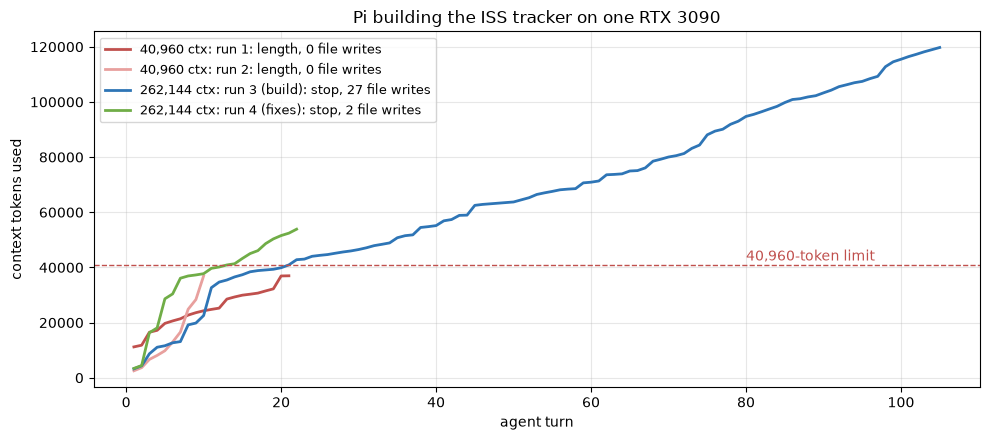

In [4]:
import matplotlib.pyplot as plt
fig, ax = plt.subplots(figsize=(10, 4.5))
style = {'run1': ('#c0504d', '40,960 ctx: run 1'), 'run2': ('#e8a09e', '40,960 ctx: run 2'),
         'run3': ('#2e75b6', '262,144 ctx: run 3 (build)'), 'run4': ('#70ad47', '262,144 ctx: run 4 (fixes)')}
for name, v in runs.items():
    xs = [t['turn'] for t in v['per_turn'] if t['context_tokens']]
    ys = [t['context_tokens'] for t in v['per_turn'] if t['context_tokens']]
    c, lab = style[name]
    ax.plot(xs, ys, color=c, lw=2, label=f"{lab}: {v['final_stop']}, {len(v['writes'])} file writes")
ax.axhline(40960, color='#c0504d', ls='--', lw=1); ax.text(80, 42500, '40,960-token limit', color='#c0504d')
ax.set_xlabel('agent turn'); ax.set_ylabel('context tokens used'); ax.set_title('Pi building the ISS tracker on one RTX 3090')
ax.legend(loc='upper left', fontsize=9); ax.grid(alpha=.3); fig.tight_layout(); fig.savefig(R/'context-per-turn.png', dpi=130)
for name, v in runs.items():
    print(f"{name}: ctx={v['max_context']:>7} turns={v['turns']:>3} stop={v['final_stop']:7} peak={v['peak_context']:>7} writes={len(v['writes']):>2} tools={v['tool_calls']}")

- **Runs 1–2 (40,960):** the agent spent its window on downloads, `npm install` and test scripts for the sun math, then stopped with
  `length`. **0 app files** written.
- **Run 3 (262,144):** 105 turns, peak 119,724 tokens, 27 file writes/edits, clean `stop`. Three turns are `error`: the SSH tunnel
  to the server timed out mid-run; Pi retried and finished. Peak use was 3× the old limit, so a 128K window is the practical floor for this task (**inferred**).
- **Run 4 (262,144):** a targeted fix prompt (4 visual issues); 22 turns, 2 edits to `index.html`, math files untouched.

## 4. Result check (measured, headless Chromium, software GL)

| check | page | reference | result |
|---|---|---|---|
| ISS position (run 4, 06:43 UTC) | N 33.69°, E 37.98° | `api.wheretheiss.at`: N 33.73°, E 38.03° (read seconds later) | match |
| Velocity | 27,565 km/h | API 27,565 km/h | match |
| Sub-solar point (run 3, 06:07 UTC) | S 4.37°, E 85.45° | hand calculation (declination + equation of time): S ≈4.4°, E ≈85.4° | match |
| Refresh | 5 s countdown | prompt: 5 s | match |
| Opening view after run 4 | ISS beacon and night side visible, thin rim, title clear | fix prompt | match |

Not checked: bloom on a real GPU, orbit controls by hand.

![run 4](receipts/iss-run4.png)

## Reproduce

```bash
# 1. Engine (Linux host, NVIDIA driver, Docker with GPU access)
docker pull ghcr.io/pixelml/strata@sha256:88b9b11628923aaf241c4805a36b0794691b1391b8160c6d2aca5cccf7311237
# or rebuild: git clone https://github.com/Niko1221/Strata && cd Strata && git checkout 7df6cbcf6dbef62ca98cddf38710ee6cde8a0f51
#   docker build --build-arg CUDA_ARCHITECTURES=86 --build-arg BUILD_VISION=0 -t strata:sm86-7df6cbc .
# follow Strata's setup.sh for IQ2_XS: it downloads the model at the pinned revision, builds the pack and MTP head,
# then set "--max-context", "262144" in data/config/strata-iq2_xs.json and start the container (port 8080)

# 2. Agent: add an OpenAI-compatible provider to ~/.pi/agent/models.json
#    baseUrl http://127.0.0.1:8080/v1, model qwen3.8-flash-next-iq2_xs, contextWindow 262144, maxTokens 16384
# 3. Keep the skill catalog small (Pi settings.json "skills" filters, or --no-skills), then:
cd app && npm install
pi --provider <your-provider> --model qwen3.8-flash-next-iq2_xs --no-session --mode json \
   -p "$(cat ../receipts/prompt.txt)" < /dev/null > run.jsonl     # note: < /dev/null, or pi -p waits on stdin
node serve.js   # http://localhost:5173
```

Textures are not redistributed. The agent fetched them from NASA Visible Earth (Blue Marble, public domain) and the three.js example
textures (MIT) (**inferred** from the run log); put them in `app/assets/textures/` with the file names `index.html` loads.

**Lessons for consumer-GPU agents:** count the system prompt before the first task; load only the skills the job needs; size the
context to the task (here ≥128K); run `pi -p` with `< /dev/null` in background jobs; keep long-lived tunnels alive past the run time.